# Tuning della Riduzione Dimensionale

Questo notebook permette di esplorare rapidamente gli iperparametri di UMAP e t-SNE su una matrice di features caricata. 

Vengono fissati i parametri "nested" (`metric`, `regress_out_volume`) e variati gli altri parametri di grid per ottenere curve di metriche (trustworthiness) e griglie di subplot degli embedding risultanti, proprio come nella pipeline di produzione.

In [1]:
import sys
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tempfile
from IPython.display import Image, display

# Aggiunge la directory root del progetto al path per importare src
# Risale da cwd fino a trovare la root del repo (contiene environment.yml) - non assume un
# numero fisso di livelli: cwd dipende da come il kernel Jupyter e' stato lanciato (IDE/editor),
# non dalla posizione del notebook sul filesystem (bug trovato 13-08: Path.cwd().parent falliva
# per i notebook annidati sotto notebooks/<sottocartella>/, es. questo file).
root_path = Path.cwd()
while not (root_path / "environment.yml").exists():
    if root_path.parent == root_path:
        raise RuntimeError(
            "could not locate project root (no environment.yml found in any parent directory of "
            f"{Path.cwd()}) - run this notebook with a working directory somewhere inside the NEMESIS repo"
        )
    root_path = root_path.parent
if str(root_path) not in sys.path:
    sys.path.append(str(root_path))

# Ripristina il backend interattivo per i plot inline nel notebook
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")

from src.utils.artifacts import load_matrix
from src.analysis.reduction import REDUCTION_METHODS, embedding_for_viz
from src.analysis.tuning import run_tuning_sweep, evaluate_umap, evaluate_tsne
from src.analysis.plotting import plot_tuning_curve, plot_embedding_grid_blocks
from src.analysis.params import load_nested_params, load_method_params, load_tuning_grid, load_trustworthiness_n_neighbors
from src.analysis.covariates import regress_out_covariate

print("Librerie importate con successo e backend matplotlib impostato per visualizzazione inline.")

/opt/anaconda3/envs/nemesis/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Librerie importate con successo e backend matplotlib impostato per visualizzazione inline.


## 1. Setup dei Percorsi e Caricamento Matrice

Definiamo il percorso della matrice lesionale costruita e carichiamo i dati.

In [2]:
# Percorso della matrice lesionale di input (modificabile all'occorrenza)
input_matrix_dir = Path("../data/derived/lesion_matrix/21-07_s1.1")

try:
    X, metadata, extra_arrays = load_matrix(input_matrix_dir)
    print(f"Matrice caricata correttamente da: {input_matrix_dir}")
    print(f"Shape di X: {X.shape[0]} soggetti x {X.shape[1]} features")
    print(f"Colonne metadati: {list(metadata.columns)}")
except Exception as e:
    print(f"Errore nel caricamento della matrice: {e}")

Matrice caricata correttamente da: ../data/derived/lesion_matrix/21-07_s1.1
Shape di X: 1150 soggetti x 254865 features
Colonne metadati: ['subject_id', 'dataset']


## 2. Definizione Configurazione e Parametri (Nested / Grid)

Definiamo la configurazione di tuning. Carichiamo le impostazioni predefinite dal registro del progetto (`config/registry/params_reduction.json`).

In [3]:
# Carica le configurazioni dal registro
params_file = Path("../config/registry/params_reduction.json")

# Scegli il metodo da testare: 'umap' oppure 'tsne'
reduction_method = "umap"  

base_params, _ = load_method_params(params_file, reduction_method)
tuning_grid = load_tuning_grid(params_file, reduction_method)
nested_params = load_nested_params(params_file, reduction_method, tuning_grid)
trustworthiness_n_neighbors = load_trustworthiness_n_neighbors(params_file, reduction_method)

print(f"Metodo selezionato: {reduction_method}")
print(f"Base params: {base_params}")
print(f"Tuning grid: {tuning_grid}")
print(f"Nested params (quelli strutturali): {nested_params}")
print(f"Vicini per calcolo della trustworthiness: {trustworthiness_n_neighbors}")

Metodo selezionato: umap
Base params: {'n_neighbors': 15, 'min_dist': 0.0, 'n_components': 2, 'random_state': 0, 'metric': 'jaccard'}
Tuning grid: {'metric': ['euclidean', 'jaccard', 'dice'], 'regress_out_volume': [False, True], 'n_neighbors': [5, 15, 30, 50, 100], 'min_dist': [0.0, 0.1, 0.25]}
Nested params (quelli strutturali): ['metric', 'regress_out_volume']
Vicini per calcolo della trustworthiness: 10


## 3. Modifica dei Nested Parameters (Fissati)

Qui fissiamo i parametri nested per questa run di tuning veloce (es. metric = 'jaccard', regress_out_volume = False). Gli altri parametri varieranno secondo la `tuning_grid`.

In [4]:
# Fissa i parametri nested per il test veloce
fixed_metric = "jaccard"  # "euclidean", "jaccard", "dice"
fixed_regress_volume = False

# Aggiorniamo base_params con i valori fissati
base_params["metric"] = fixed_metric
base_params["regress_out_volume"] = fixed_regress_volume

# Rimuoviamo i parametri nested dalla griglia di sweep in modo che vengano trattati come fissati
sweep_grid = {k: v for k, v in tuning_grid.items() if k not in nested_params}

print(f"Parametri nested fissati per lo sweep:")
print(f" - metric: {fixed_metric}")
print(f" - regress_out_volume: {fixed_regress_volume}")
print(f"Nuova griglia di sweep (free parameters): {sweep_grid}")

Parametri nested fissati per lo sweep:
 - metric: jaccard
 - regress_out_volume: False
Nuova griglia di sweep (free parameters): {'n_neighbors': [5, 15, 30, 50, 100], 'min_dist': [0.0, 0.1, 0.25]}


## 4. Esecuzione dello Sweep di Tuning

Eseguiamo lo sweep sui parametri rimasti liberi. La funzione `run_tuning_sweep` calcola la trustworthiness per ciascuna combinazione.

In [5]:
# Eseguiamo lo sweep in memoria
results, embeddings_by_combo = run_tuning_sweep(
    reduction_method, X, base_params, sweep_grid, trustworthiness_n_neighbors
)

# Mostra la tabella dei risultati ordinata per trustworthiness decrescente
results_sorted = results.sort_values(by="trustworthiness", ascending=False)
display(results_sorted)

/opt/anaconda3/envs/nemesis/lib/python3.11/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/opt/anaconda3/envs/nemesis/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/envs/nemesis/lib/python3.11/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/opt/anaconda3/envs/nemesis/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/envs/nemesis/lib/python3.11/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precompute

,n_neighbors,min_dist,trustworthiness
4,15,0.10,0.945542
3,15,0.00,0.945468
1,5,0.10,0.943139
5,15,0.25,0.943128
0,5,0.00,0.942664
2,5,0.25,0.940871
6,30,0.00,0.940631
7,30,0.10,0.940218
8,30,0.25,0.933788
9,50,0.00,0.933245


## 5. Visualizzazione dei Risultati (Curve o Griglie)

A seconda di quanti parametri sono stati variati:
- Se **un solo parametro** è variato (es. solo perplexity per t-SNE), mostriamo la curva di tuning.
- Se **più parametri** sono variati, mostriamo la griglia di subplot degli embedding corrispondenti per ispezionare visivamente lo spazio di embedding.

Costruisco la griglia degli embedding per i parametri variati...


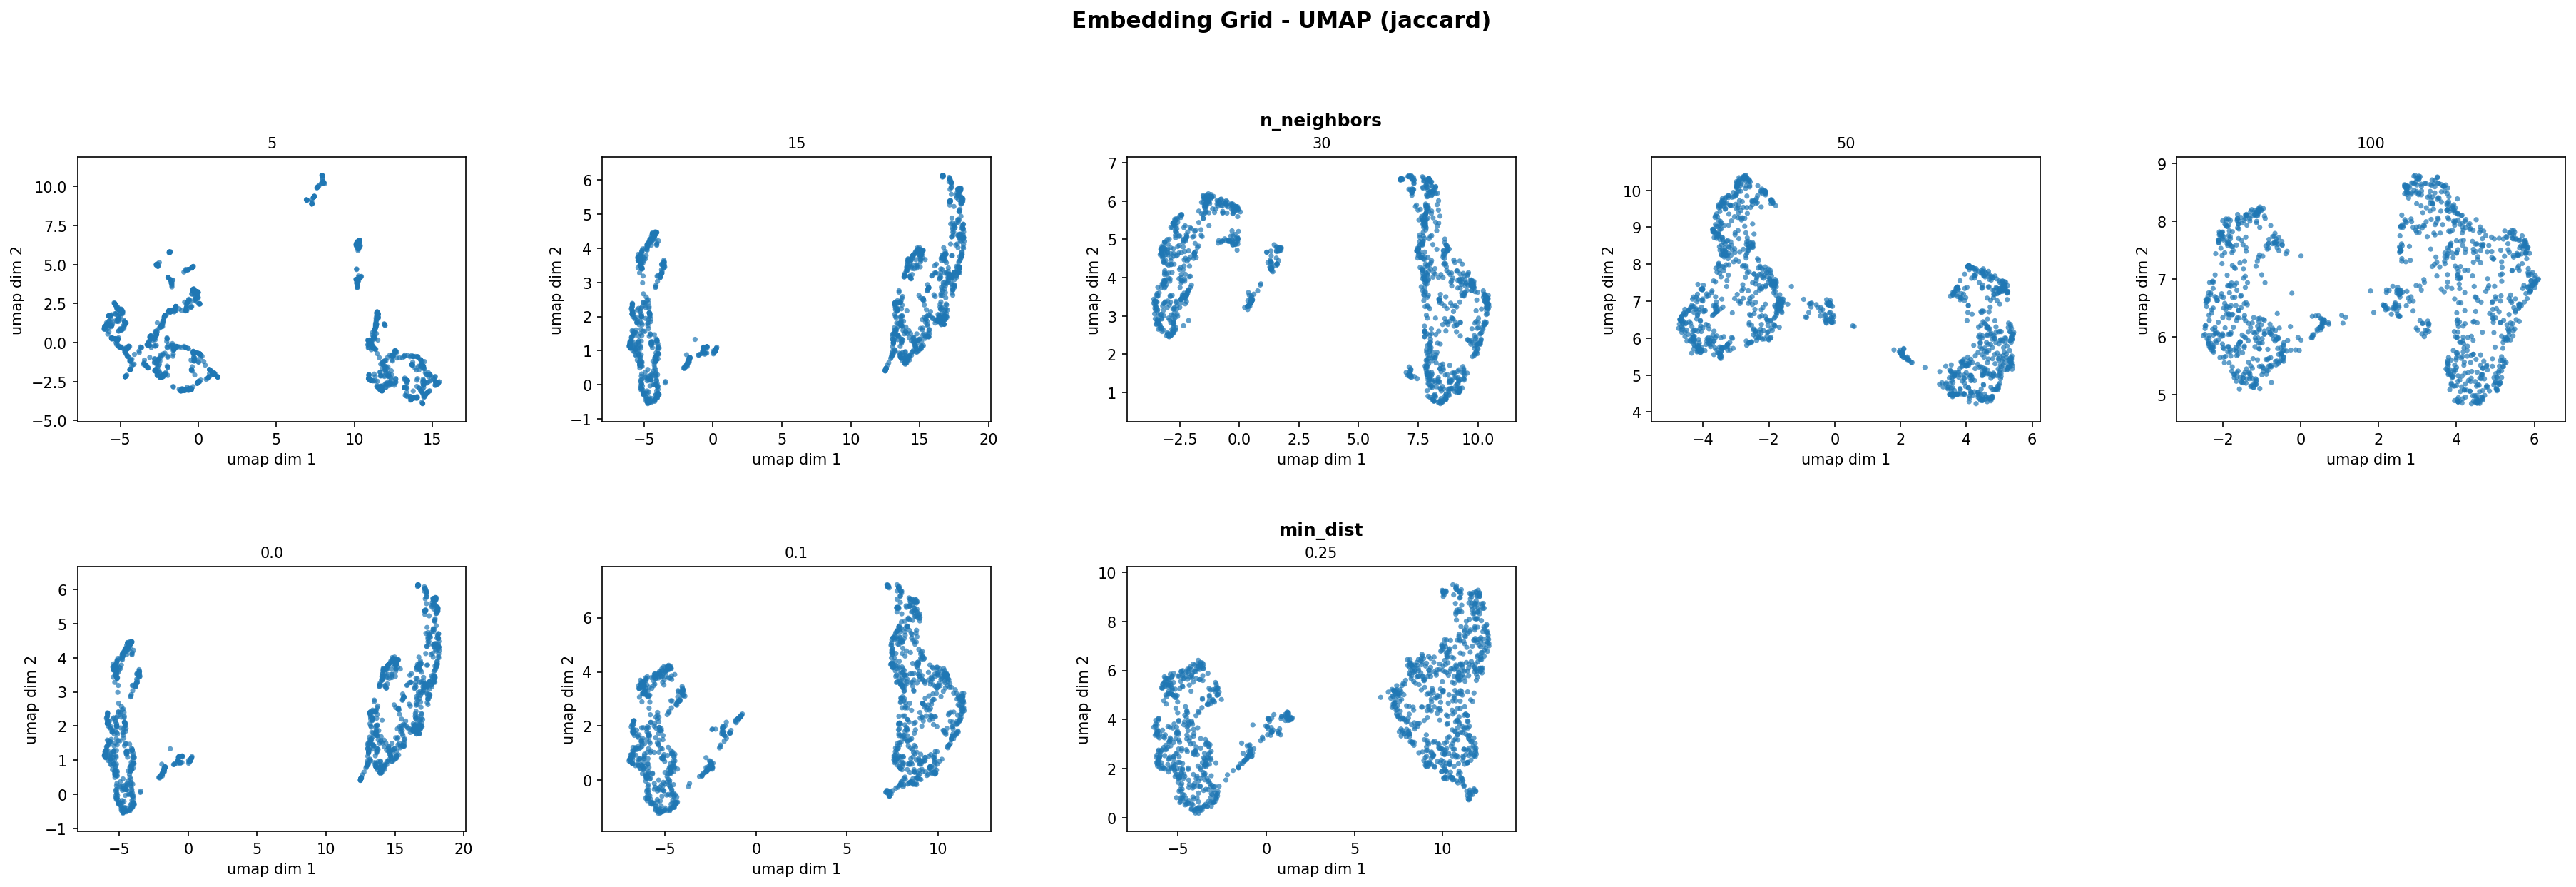

In [6]:
free_params = list(sweep_grid.keys())
metric_col = "trustworthiness"
lesion_volume_voxels = X.sum(axis=1)

# Costruisce la griglia degli embedding
print("Costruisco la griglia degli embedding per i parametri variati...")

# Costruiamo i blocchi per la visualizzazione grid
keys = list(sweep_grid.keys())

blocks = []
for varying in free_params:
    held_params = [p for p in free_params if p != varying]
    cells = []
    for value in sweep_grid[varying]:
        combo_values = []
        for key in keys:
            if key == varying:
                combo_values.append(value)
            else:
                combo_values.append(base_params[key])
        
        combo = tuple(combo_values)
        if combo not in embeddings_by_combo:
            continue
            
        embedding = embeddings_by_combo[combo]
        reduction_params_for_combo = {**base_params, **dict(zip(keys, combo))}
        
        # Forza la visualizzazione in 2D per il subplot
        viz_emb = embedding_for_viz(
            reduction_method, X, reduction_params_for_combo, embedding, 2
        )
        # Regress out the volume on the viz embedding too if needed, per src pipeline
        if fixed_regress_volume and viz_emb is not embedding:
            viz_emb = regress_out_covariate(viz_emb, lesion_volume_voxels)
        
        cells.append((str(value), viz_emb))
    blocks.append((varying, cells))
    
# Plottiamo la griglia degli embedding
with tempfile.NamedTemporaryFile(suffix=".png", delete=False) as tmpfile:
    tmp_path = Path(tmpfile.name)
    
try:
    plot_embedding_grid_blocks(
        blocks, 
        tmp_path, 
        f"{reduction_method} dim 1", 
        f"{reduction_method} dim 2", 
        f"Embedding Grid - {reduction_method.upper()} ({fixed_metric})"
    )
    display(Image(filename=tmp_path, width=850))
finally:
    if tmp_path.exists():
        tmp_path.unlink()

## 6. Confronto `n_components` (rendimenti marginali)

**Attenzione**: la trustworthiness **non è confrontabile in valore assoluto tra `n_components` diversi** (cresce quasi meccanicamente con più dimensioni disponibili — vedi `docs/knowledge/dim_reduction_tuning_guide.md`). Non si può quindi guardare "quale `n_components` ha il punteggio più alto".

Quello che si può leggere è il **guadagno marginale**: quanto sale la trustworthiness passando da un `n_components` al successivo, a parità di `(n_neighbors, min_dist)` — cercando il punto oltre il quale il guadagno si appiattisce (stessa logica della curva a gomito già usata per la varianza spiegata di PCA, ma letta come derivata, non come valore assoluto).

Legge direttamente i CSV di tuning già su disco (`results/lesion/dim_reduction/umap/tuning/03-08_s1.1/tuning_results.csv`, aggregato su tutte le foglie `metric`×`regress_out_volume`×`n_components`) — nessun nuovo calcolo, nessuna nuova funzione in `src/`. Solo UMAP: t-SNE resta a `n_components` fisso a 2 in questo progetto (mai sweeppato), quindi non c'è nulla da confrontare.

In [ ]:
tuning_dir = Path("../results/lesion/dim_reduction/umap/tuning/03-08_s1.1")
agg = pd.read_csv(tuning_dir / "tuning_results.csv")

n_components_values = sorted(agg["n_components"].unique())
combos = sorted(agg[["metric", "regress_out_volume"]].drop_duplicates().itertuples(index=False, name=None))

fig, axes = plt.subplots(1, len(combos), figsize=(4.5 * len(combos), 4.5), sharey=True)
if len(combos) == 1:
    axes = [axes]

for ax, (metric, regress) in zip(axes, combos):
    sub = agg[(agg["metric"] == metric) & (agg["regress_out_volume"] == regress)]

    # una linea per ogni combinazione di parametri liberi (n_neighbors, min_dist),
    # a parità di quei parametri, lungo n_components — mai confrontando linee diverse tra loro
    for (nn, md), grp in sub.groupby(["n_neighbors", "min_dist"]):
        grp = grp.sort_values("n_components")
        ax.plot(grp["n_components"], grp["trustworthiness"], marker="o", alpha=0.35, color="tab:blue", linewidth=1)

    mean_line = sub.groupby("n_components")["trustworthiness"].mean().reindex(n_components_values)
    ax.plot(mean_line.index, mean_line.values, marker="o", color="tab:red", linewidth=2.5, label="media sui parametri liberi")

    ax.set_title(f"{metric}\nregress_out_volume={regress}")
    ax.set_xlabel("n_components")
    ax.set_xticks(n_components_values)
    ax.legend(fontsize=8)

axes[0].set_ylabel("trustworthiness")
fig.suptitle(
    "UMAP — trustworthiness al variare di n_components, a parità di (n_neighbors, min_dist)\n"
    "(03-08_s1.1 — leggere solo la pendenza/il guadagno marginale, mai il valore assoluto tra n_components diversi)"
)
fig.tight_layout()
plt.show()

print("Guadagno marginale medio (Δ trustworthiness) tra n_components successivi:\n")
for metric, regress in combos:
    sub = agg[(agg["metric"] == metric) & (agg["regress_out_volume"] == regress)]
    means = sub.groupby("n_components")["trustworthiness"].mean().reindex(n_components_values)
    deltas = means.diff().dropna()
    delta_str = ", ".join(
        f"{n_components_values[i]}→{n_components_values[i + 1]}: {d:+.4f}" for i, d in enumerate(deltas.values)
    )
    print(f"{metric:10s} regress_out_volume={str(regress):5s}: {delta_str}")